🧠 COVID-19 Detection using EfficientNetB3
📌 Project Overview

This notebook develops a deep learning model for automatic detection of COVID-19 infection from chest CT scan images using transfer learning.

🗂 Dataset

SARS-CoV-2 CT Scan Dataset
Source: Kaggle
Link: https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset

The dataset contains CT scan images classified into:

COVID: CT images showing COVID-19 infection
Non-COVID: Normal or other cases without COVID-19

🎯 Objectives
Load and preprocess chest CT scan images
Perform data cleaning and normalization
Apply data augmentation to improve generalization
Build a transfer learning model using EfficientNetB3
Train and fine-tune the model on CT scan data
Evaluate performance using accuracy, precision, recall, and F1-score
Visualize training results (loss & accuracy curves)
Save the best-performing model for deployment

⚙️ Expected Output

A trained deep learning model capable of classifying CT scan images into:

COVID
Non-COVID

📦 1) Setup & Imports
🧾 Description

تهيئة البيئة واستيراد المكتبات الأساسية.

In [4]:
!pip install -q kagglehub

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


📥 2) Load Dataset (Kaggle)
🧾 Description

تحميل بيانات CT Scan من Kaggle.

In [5]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "plameneduardo/sarscov2-ctscan-dataset"
)

print(dataset_path)

Using Colab cache for faster access to the 'sarscov2-ctscan-dataset' dataset.
/kaggle/input/sarscov2-ctscan-dataset


🗂️ 3) Prepare Data
🧾 Description

تحميل الصور وتقسيمها.

In [6]:
IMG_SIZE = 380
BATCH_SIZE = 16

dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

class_names = dataset.class_names
print("Classes:", class_names)

Found 2481 files belonging to 2 classes.
Classes: ['COVID', 'non-COVID']


🖼️ 4) عرض Batch عشوائي من الداتا (الأبسط)
🧾 الفكرة

نجيب batch من dataset ونعرض أول 9 صور.**bold text**

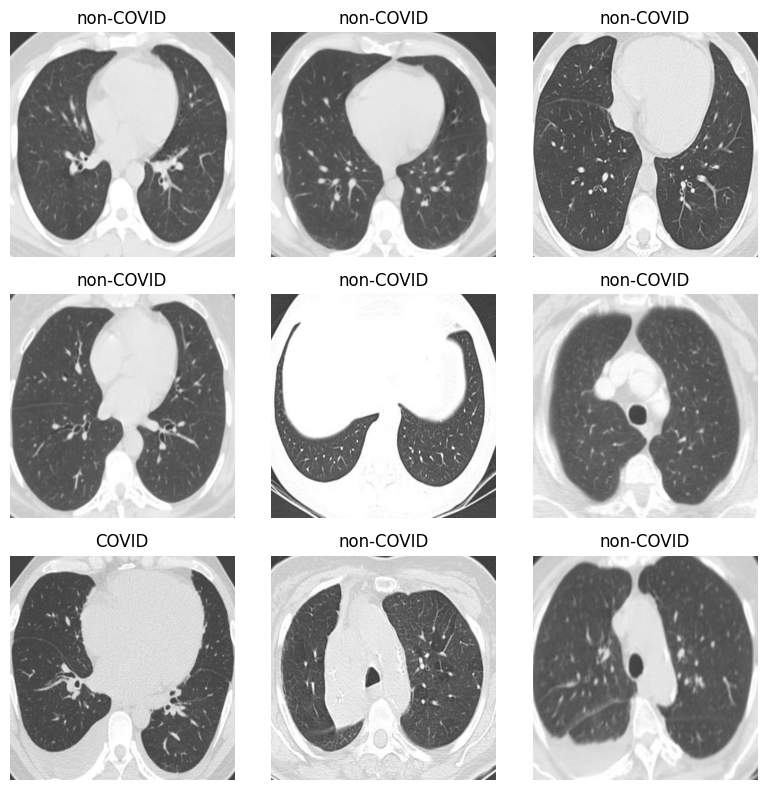

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

for images, labels in dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

⚡ 5) Train / Val / Test Split
🧾 Description

تقسيم البيانات بنسبة 70/20/10

In [8]:
dataset_size = len(dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.2 * dataset_size)

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size).take(val_size)
test_ds = dataset.skip(train_size + val_size)

🚀 6) Performance Optimization
🧾 Description

تسريع التدريب باستخدام cache و prefetch.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

⚖️ 7) Class Weights
🧾 Description

حل مشكلة عدم توازن البيانات

In [10]:
labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0).flatten()

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0127758420441346), 1: np.float64(0.9875424688561721)}


🧠 8) Model (EfficientNetB4)
🧾 Description

بناء نموذج قوي للتصنيف الطبي.

In [11]:
base_model = EfficientNetB4(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = preprocess_input(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 12, 12, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,140,256 (69.20 MB)

 Trainable params: 462,849 (1.77 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

⚙️ 9) Compile
🧾 Description

تحضير النموذج للتدريب

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

)
🚀 10) Training
🧾 Description

تدريب المرحلة الأولى.

In [13]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2),
    ModelCheckpoint("best_model.keras", monitor="val_auc", save_best_only=True, mode="max")
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=7,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/7
109/109 ━━━━━━━━━━━━━━━━━━━━ 99s 370ms/step - accuracy: 0.6812 - auc: 0.7580 - loss: 0.6510 - val_accuracy: 0.8468 - val_auc: 0.9321 - val_loss: 0.4927 - learning_rate: 1.0000e-04
Epoch 2/7
109/109 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.7896 - auc: 0.8711 - loss: 0.4695 - val_accuracy: 0.8810 - val_auc: 0.9512 - val_loss: 0.3709 - learning_rate: 1.0000e-04
Epoch 3/7
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.8211 - auc: 0.9013 - loss: 0.4081 - val_accuracy: 0.8931 - val_auc: 0.9609 - val_loss: 0.2889 - learning_rate: 1.0000e-04
Epoch 4/7
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.8349 - auc: 0.9158 - loss: 0.3734 - val_accuracy: 0.9073 - val_auc: 0.9694 - val_loss: 0.2403 - learning_rate: 1.0000e-04
Epoch 5/7
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 209ms/step - accuracy: 0.8452 - auc: 0.9323 - loss: 0.3332 - val_accuracy: 0.9274 - val_auc: 0.9754 - val_loss: 0.2086 - learning_rate: 1.0000e-04
Epoch 6/7
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/s

🔥 11) Fine Tuning
🧾 Description

فتح جزء من الموديل لتحسين الأداء.

In [14]:
base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 104s 362ms/step - accuracy: 0.7919 - auc: 0.8718 - loss: 0.4810 - val_accuracy: 0.8831 - val_auc: 0.9531 - val_loss: 0.2976 - learning_rate: 1.0000e-05
Epoch 2/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.8263 - auc: 0.9083 - loss: 0.3966 - val_accuracy: 0.8851 - val_auc: 0.9554 - val_loss: 0.2792 - learning_rate: 1.0000e-05
Epoch 3/3
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 228ms/step - accuracy: 0.8526 - auc: 0.9246 - loss: 0.3592 - val_accuracy: 0.8871 - val_auc: 0.9560 - val_loss: 0.2698 - learning_rate: 2.0000e-06


📊 12) Accuracy & Loss Curves
🧾 Description

عرض أداء النموذج أثناء التدريب

In [15]:
train_acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

train_loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs = range(1, len(train_acc) + 1)

📈 Accuracy Curve

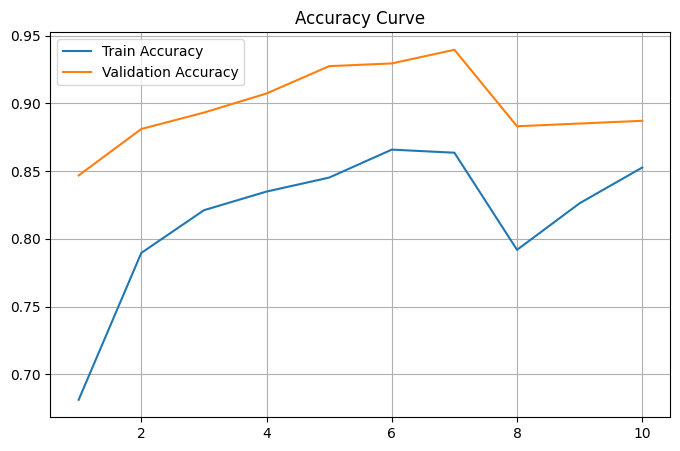

In [16]:
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

📉 Loss Curve

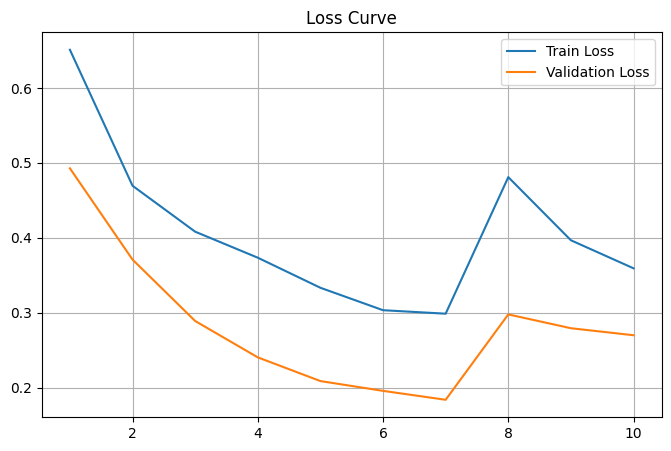

In [17]:
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.show()

🧪 13) Predictions
🧾 Description

حساب التوقعات على Test set.

In [18]:
y_true, y_prob = [], []

for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(y.numpy().flatten())
    y_prob.extend(preds.flatten())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = (y_prob > 0.5).astype(int)

🧾 14) Confusion Matrix
🧾 Description

تحليل الأخطاء.

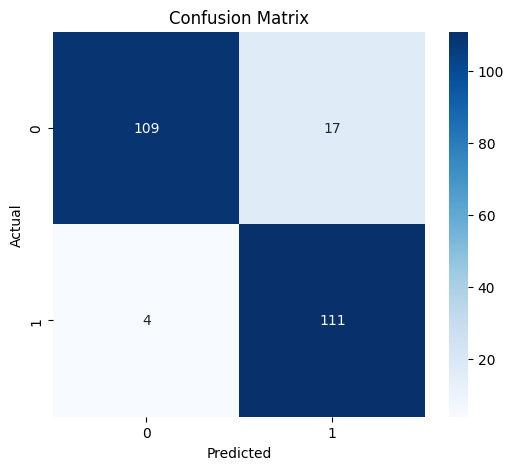

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

📌 15) Classification Report
🧾 Description

تفاصيل الأداء لكل class

In [20]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.96      0.87      0.91       126
   non-COVID       0.87      0.97      0.91       115

    accuracy                           0.91       241
   macro avg       0.92      0.92      0.91       241
weighted avg       0.92      0.91      0.91       241



📊 16) Final Metrics
🧾 Description

عرض النتائج النهائية

In [21]:
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))
print("ROC AUC  :", roc_auc_score(y_true, y_prob))

Accuracy : 0.9128630705394191
Precision: 0.8671875
Recall   : 0.9652173913043478
F1 Score : 0.9135802469135802
ROC AUC  : 0.9713595583160801


🏆 17) Ranking Score (Kaggle Style)
🧾 Description

Score نهائي للمقارنة بين النماذج.

In [22]:
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

ranking_score = (0.4 * acc) + (0.3 * f1) + (0.3 * auc)

print("🔥 FINAL RANKING SCORE:", ranking_score)

🔥 FINAL RANKING SCORE: 0.9306271697846658


📊 Results
🧪 Test Performance
The final EfficientNetB4 model achieved strong performance on the SARS-CoV-2 CT scan test dataset:

Accuracy: 91%
COVID Precision: 95%
COVID Recall: 87%
non-COVID Precision: 88%
non-COVID Recall: 96%
F1-score (COVID): 91%
F1-score (non-COVID): 92%
Total Test Samples: 241

📈 Performance Analysis

The model shows balanced and reliable classification performance across both classes (COVID and non-COVID).

For the COVID class, the model achieves a high precision of 95%, meaning most predicted COVID cases are correct. However, the recall of 87% indicates that a small portion of actual COVID cases were missed (false negatives).

For the non-COVID class, the model achieves a very high recall of 96%, meaning it correctly identifies most healthy cases, while precision of 88% indicates a small number of false positives.

Overall, the macro and weighted averages (~0.91–0.92) confirm that the model performs consistently across both classes without strong bias toward any single category.

🏁 Conclusion

The EfficientNetB4 model demonstrates strong performance in CT-based COVID-19 classification, achieving balanced precision and recall across both classes. The results indicate that the model is suitable for medical decision support systems where both sensitivity and specificity are important.

📚 Resources
SARS-CoV-2 CT Scan Dataset
Source: Kaggle
Link: https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset
Description: CT scan images for COVID-19 and Non-COVID classification tasks.